Diabetes Prediction Project

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

In [5]:
diabetesData = "diabetes_binary_health_indicators_BRFSS2015.csv"

df = pd.read_csv(diabetesData)

In [6]:
dataTypes = df.dtypes
missingValues = df.isnull().sum()
duplicateRows = df.duplicated().sum()
targetDistribution = df['Diabetes_binary'].value_counts()/len(df) * 100
print("Data Types:\n", dataTypes)
print("Missing Values:\n", missingValues)
print("\nDuplicate Rows:", duplicateRows)
print("\nTarget Distribution:\n", targetDistribution)


Data Types:
 Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object
Missing Values:
 Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits            

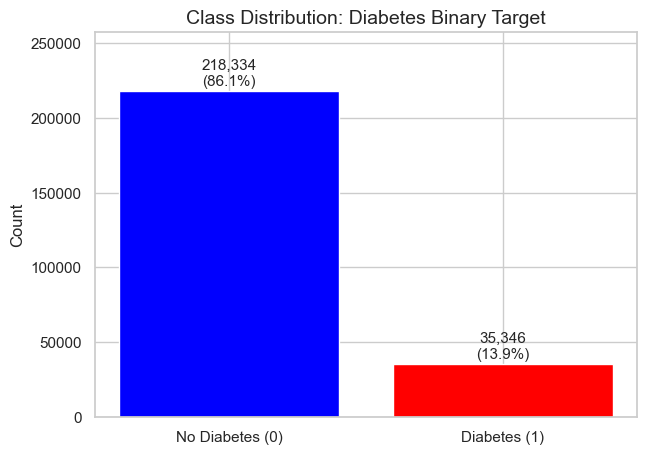

Saved: fig1_class_distribution.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

counts = df['Diabetes_binary'].value_counts().sort_index()
labels = ['No Diabetes (0)', 'Diabetes (1)']
colors = ['blue', 'red']

bars = ax.bar(labels, counts.values, color=colors, edgecolor='white')

for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1500,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Class Distribution: Diabetes Binary Target', fontsize=14)
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, counts.max() * 1.18)

plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_class_distribution.png")


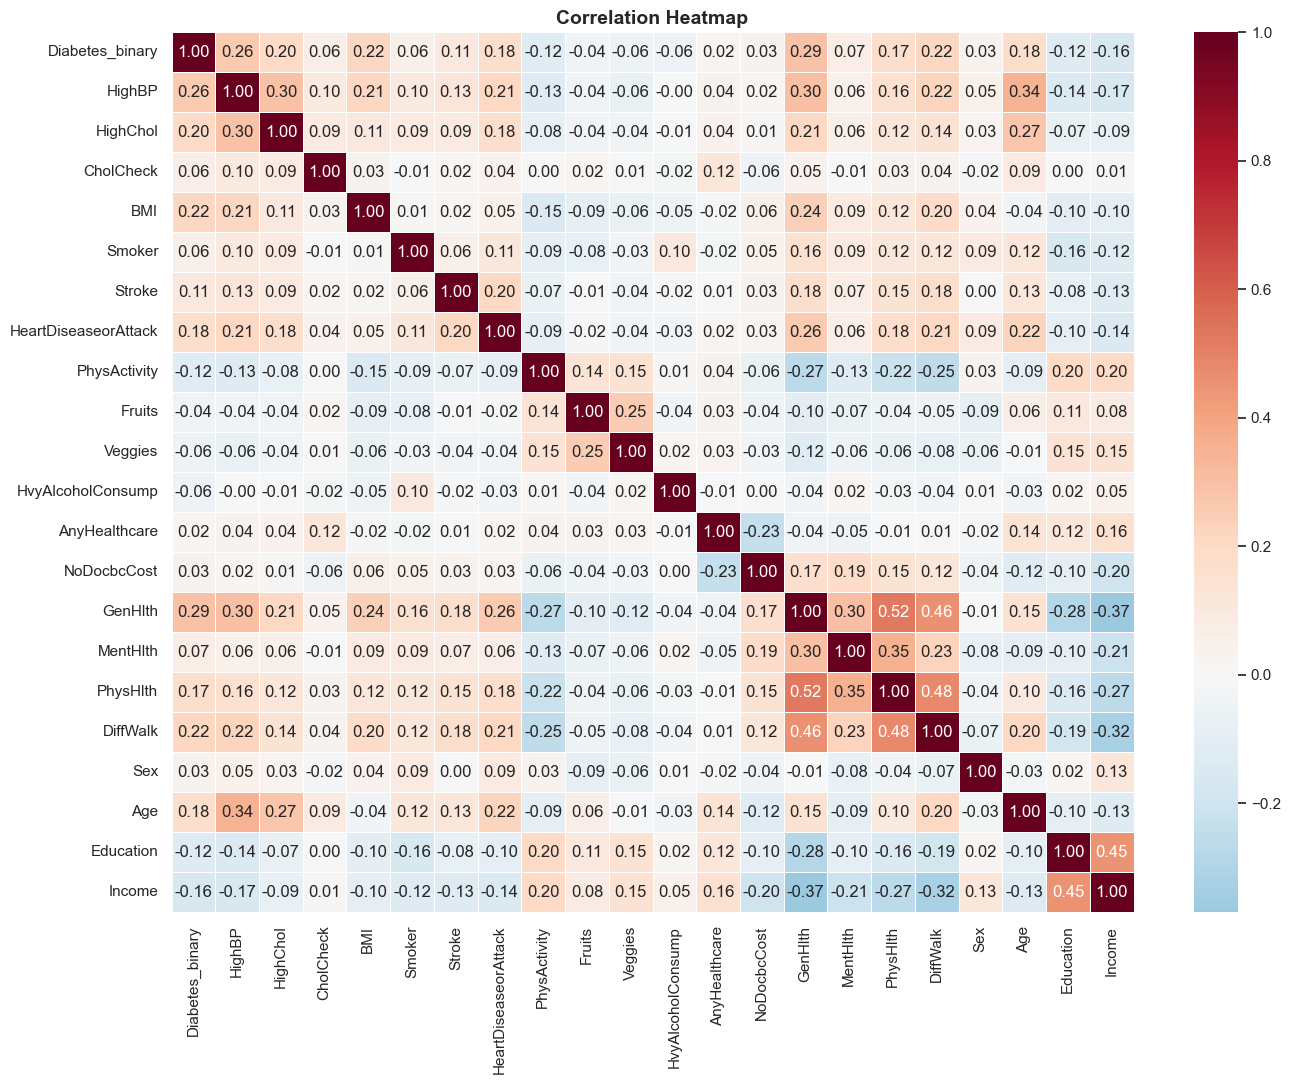

Top 10 features correlated with Diabetes:
 GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Income                  0.163919
Education               0.124456
Name: Diabetes_binary, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(14, 11))

correlationMatrix = df.corr(method='pearson')
sns.heatmap(correlationMatrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5, ax=ax)

ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

target_corr = correlationMatrix['Diabetes_binary'].drop('Diabetes_binary').abs().sort_values(ascending=False)
print("Top 10 features correlated with Diabetes:\n", target_corr.head(10))


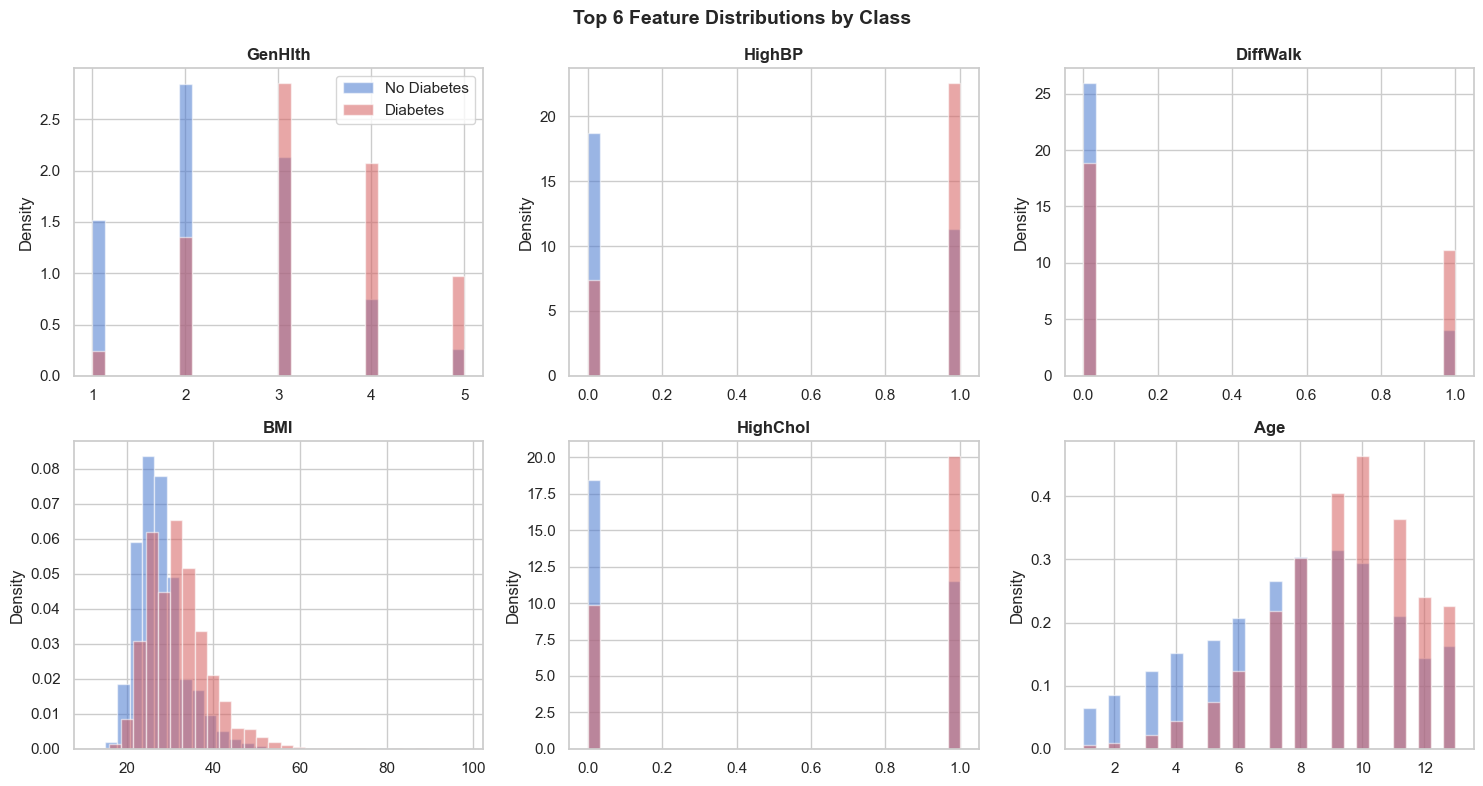

Saved: fig3_feature_histograms.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

top6 = target_corr.head(6).index.tolist()

for i, feat in enumerate(top6):
    ax = axes[i]
    ax.hist(df[df['Diabetes_binary'] == 0][feat], bins=30, density=True, alpha=0.55, color='#4878CF', label='No Diabetes')
    ax.hist(df[df['Diabetes_binary'] == 1][feat], bins=30, density=True, alpha=0.55, color='#D65F5F', label='Diabetes')
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend()

plt.suptitle('Top 6 Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_feature_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_feature_histograms.png")


PC1 variance explained: 0.170
PC2 variance explained: 0.084
Total: 0.254


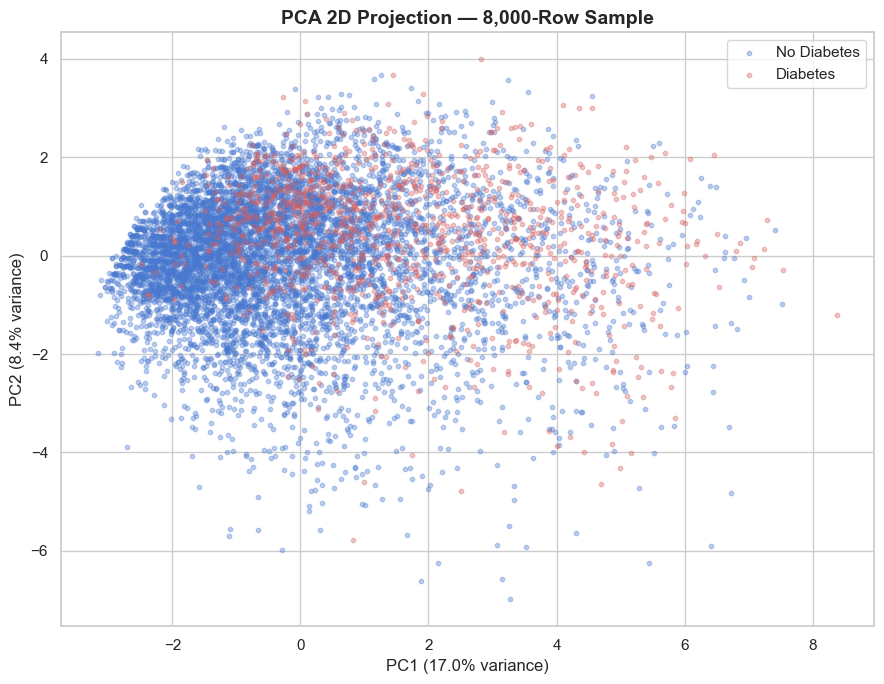

Saved: fig4_pca_scatter.png


In [10]:
np.random.seed(42)
sample_idx = np.random.choice(len(df), size=8000, replace=False)
X_sample = df.drop('Diabetes_binary', axis=1).values[sample_idx]
y_sample = df['Diabetes_binary'].values[sample_idx]

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_sample)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1 variance explained: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2 variance explained: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Total: {pca.explained_variance_ratio_.sum():.3f}")

fig, ax = plt.subplots(figsize=(9, 7))
for cls, label, color in [(0, 'No Diabetes', '#4878CF'), (1, 'Diabetes', '#D65F5F')]:
    mask = y_sample == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label, alpha=0.35, s=10)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA 2D Projection — 8,000-Row Sample', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_pca_scatter.png")


In [11]:
# Step 1: Drop duplicates
df_clean = df.drop_duplicates()
print(f"Rows after dropping duplicates: {len(df_clean):,} (removed {len(df) - len(df_clean):,})")

# Step 2: Separate features and target
X = df_clean.drop('Diabetes_binary', axis=1).values
y = df_clean['Diabetes_binary'].values
feature_names = df_clean.drop('Diabetes_binary', axis=1).columns.tolist()

# Step 3: 70/15/15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train: {len(y_train):,} | Val: {len(y_val):,} | Test: {len(y_test):,}")

# Step 4: Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Scaling complete.")


Rows after dropping duplicates: 229,474 (removed 24,206)
Train: 160,631 | Val: 34,421 | Test: 34,422
Scaling complete.


In [12]:
# Helper function to evaluate any model
def eval_model(model, X, y, name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    acc = accuracy_score(y, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y, y_pred, average='binary')
    auc = roc_auc_score(y, y_proba)
    print(f"\n--- {name} ---")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC': auc}

# Train both models
lr_vanilla = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs', C=1.0)
lr_vanilla.fit(X_train_s, y_train)

lr_balanced = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs', C=1.0, class_weight='balanced')
lr_balanced.fit(X_train_s, y_train)

# Evaluate on validation set
print("=== Validation Metrics ===")
val_vanilla = eval_model(lr_vanilla, X_val_s, y_val, 'LR Vanilla')
val_balanced = eval_model(lr_balanced, X_val_s, y_val, 'LR Balanced')


=== Validation Metrics ===

--- LR Vanilla ---
  Accuracy:  0.8517
  Precision: 0.5535
  Recall:    0.1582
  F1:        0.2461
  ROC-AUC:   0.8120

--- LR Balanced ---
  Accuracy:  0.7172
  Precision: 0.3215
  Recall:    0.7642
  F1:        0.4526
  ROC-AUC:   0.8126


In [13]:
# Architecture A: single hidden layer
mlp_a = MLPClassifier(hidden_layer_sizes=(32,), activation='relu', solver='adam',
                      max_iter=100, early_stopping=True, validation_fraction=0.1,
                      n_iter_no_change=10, random_state=42, learning_rate_init=0.001)
mlp_a.fit(X_train_s, y_train)
print(f"MLP Arch A (32,) — iterations: {mlp_a.n_iter_}")

# Architecture B: two hidden layers
mlp_b = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                      max_iter=100, early_stopping=True, validation_fraction=0.1,
                      n_iter_no_change=10, random_state=42, learning_rate_init=0.001)
mlp_b.fit(X_train_s, y_train)
print(f"MLP Arch B (64,32) — iterations: {mlp_b.n_iter_}")

# Evaluate both on validation set
print("\n=== MLP Validation Metrics ===")
val_mlp_a = eval_model(mlp_a, X_val_s, y_val, 'MLP Arch A (32,)')
val_mlp_b = eval_model(mlp_b, X_val_s, y_val, 'MLP Arch B (64,32)')

# Pick the better one by F1
best_mlp = mlp_a if val_mlp_a['F1'] >= val_mlp_b['F1'] else mlp_b
best_mlp_name = 'MLP_ArchA_32' if val_mlp_a['F1'] >= val_mlp_b['F1'] else 'MLP_ArchB_64_32'
print(f"\nSelected: {best_mlp_name}")


MLP Arch A (32,) — iterations: 25
MLP Arch B (64,32) — iterations: 13

=== MLP Validation Metrics ===

--- MLP Arch A (32,) ---
  Accuracy:  0.8545
  Precision: 0.5920
  Recall:    0.1571
  F1:        0.2483
  ROC-AUC:   0.8178

--- MLP Arch B (64,32) ---
  Accuracy:  0.8544
  Precision: 0.5901
  Recall:    0.1581
  F1:        0.2493
  ROC-AUC:   0.8176

Selected: MLP_ArchB_64_32


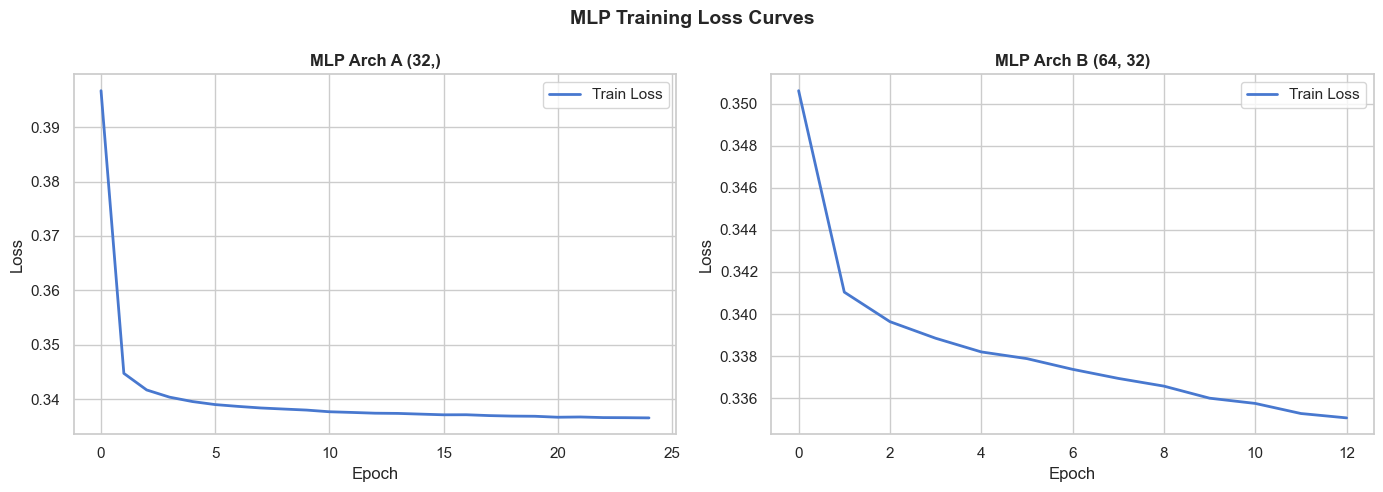

Saved: fig5_mlp_loss_curve.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mlp, name in zip(axes, [mlp_a, mlp_b], ['Arch A (32,)', 'Arch B (64, 32)']):
    ax.plot(mlp.loss_curve_, color='#4878CF', linewidth=2, label='Train Loss')
    ax.set_title(f'MLP {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('MLP Training Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_mlp_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_mlp_loss_curve.png")


In [15]:
print("=== Final Test Set Evaluation ===")
test_vanilla  = eval_model(lr_vanilla,  X_test_s, y_test, 'LR Vanilla')
test_balanced = eval_model(lr_balanced, X_test_s, y_test, 'LR Balanced')
test_mlp      = eval_model(best_mlp,    X_test_s, y_test, best_mlp_name)

results_df = pd.DataFrame([test_vanilla, test_balanced, test_mlp]).round(4)
print("\n=== Metrics Table ===")
print(results_df.to_string(index=False))


=== Final Test Set Evaluation ===

--- LR Vanilla ---
  Accuracy:  0.8502
  Precision: 0.5360
  Recall:    0.1525
  F1:        0.2375
  ROC-AUC:   0.8070

--- LR Balanced ---
  Accuracy:  0.7134
  Precision: 0.3175
  Recall:    0.7603
  F1:        0.4479
  ROC-AUC:   0.8074

--- MLP_ArchB_64_32 ---
  Accuracy:  0.8530
  Precision: 0.5780
  Recall:    0.1436
  F1:        0.2300
  ROC-AUC:   0.8139

=== Metrics Table ===
          Model  Accuracy  Precision  Recall     F1  ROC_AUC
     LR Vanilla    0.8502     0.5360  0.1525 0.2375   0.8070
    LR Balanced    0.7134     0.3175  0.7603 0.4479   0.8074
MLP_ArchB_64_32    0.8530     0.5780  0.1436 0.2300   0.8139


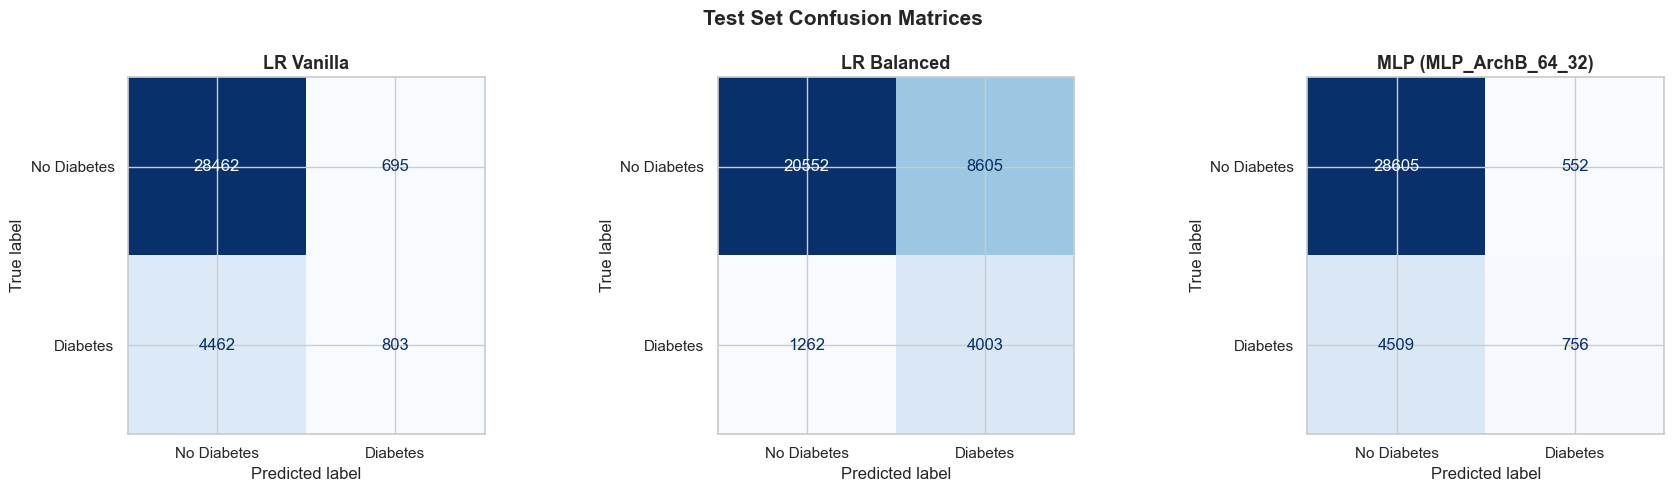

Saved: fig6_confusion_matrices.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [(lr_vanilla, 'LR Vanilla'), (lr_balanced, 'LR Balanced'), (best_mlp, f'MLP ({best_mlp_name})')]

for ax, (model, name) in zip(axes, models):
    y_pred = model.predict(X_test_s)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Test Set Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig6_confusion_matrices.png")


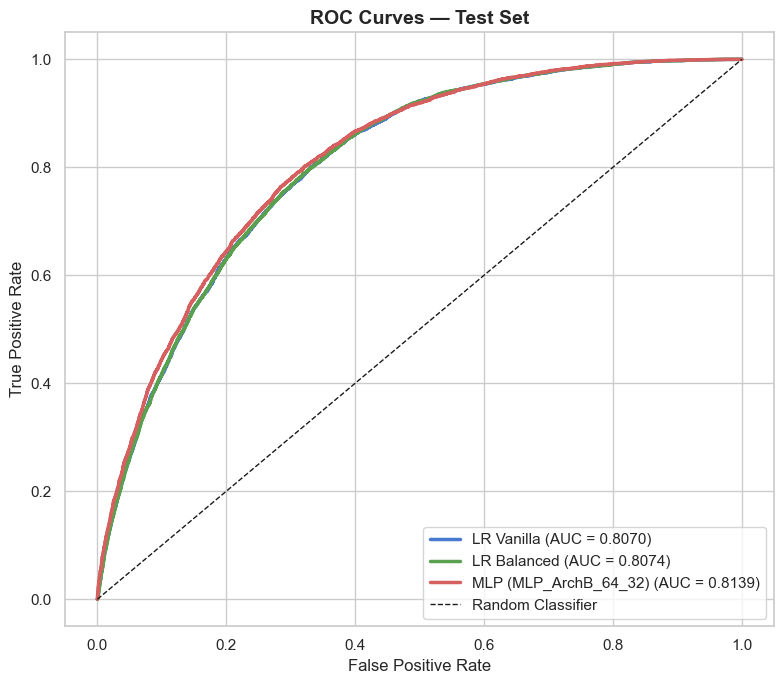

Saved: fig7_roc_curves.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 7))

models_roc = [
    (lr_vanilla,  'LR Vanilla',        '#4878CF'),
    (lr_balanced, 'LR Balanced',       '#59A14F'),
    (best_mlp,    f'MLP ({best_mlp_name})', '#D65F5F')
]

for model, name, color in models_roc:
    y_proba = model.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Test Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.savefig('fig7_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig7_roc_curves.png")


             Feature  Abs_Coefficient  Raw_Coefficient Direction
             GenHlth           0.5337           0.5337  Positive
                 BMI           0.3936           0.3936  Positive
                 Age           0.3702           0.3702  Positive
              HighBP           0.3660           0.3660  Positive
            HighChol           0.2813           0.2813  Positive
           CholCheck           0.2523           0.2523  Positive
   HvyAlcoholConsump           0.1845          -0.1845  Negative
                 Sex           0.1280           0.1280  Positive
              Income           0.0887          -0.0887  Negative
HeartDiseaseorAttack           0.0668           0.0668  Positive


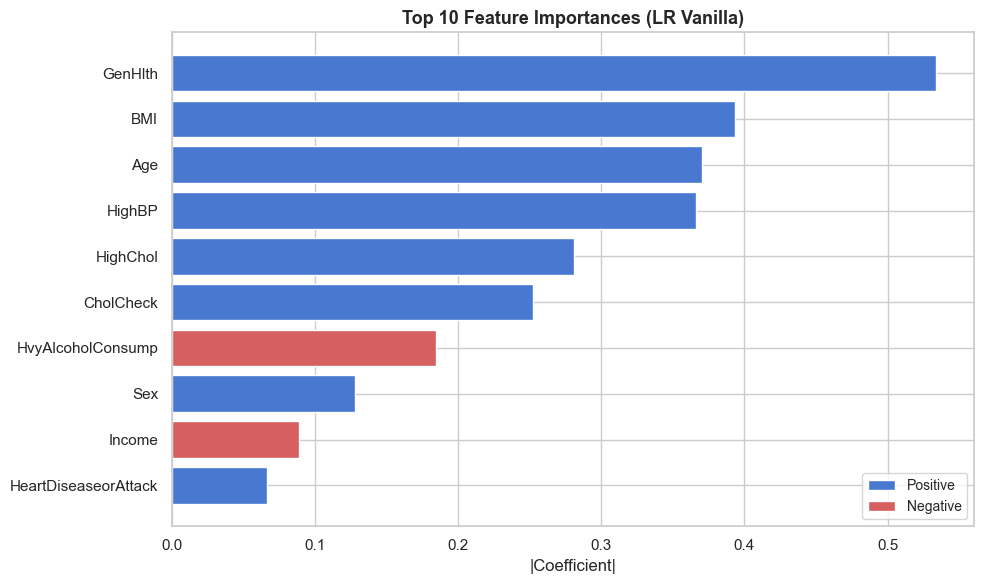

Saved: fig8_feature_importance.png


In [18]:
coef = lr_vanilla.coef_[0]
coef_series = pd.Series(np.abs(coef), index=feature_names).sort_values(ascending=False)
top10 = coef_series.head(10)
top10_signed = pd.Series(coef, index=feature_names).loc[top10.index]

coef_table = pd.DataFrame({
    'Feature': top10.index,
    'Abs_Coefficient': top10.values.round(4),
    'Raw_Coefficient': top10_signed.values.round(4),
    'Direction': ['Positive' if c > 0 else 'Negative' for c in top10_signed.values]
})
print(coef_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#4878CF' if c > 0 else '#D65F5F' for c in top10_signed.values[::-1]]
ax.barh(top10.index[::-1], top10.values[::-1], color=colors_bar, edgecolor='white')

legend_elements = [Patch(facecolor='#4878CF', label='Positive'), Patch(facecolor='#D65F5F', label='Negative')]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_xlabel('|Coefficient|', fontsize=12)
ax.set_title('Top 10 Feature Importances (LR Vanilla)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig8_feature_importance.png")


In [19]:
results_df.to_csv('test_results_summary.csv', index=False)
print("Saved: test_results_summary.csv")
print(pd.read_csv('test_results_summary.csv').to_string(index=False))


Saved: test_results_summary.csv
          Model  Accuracy  Precision  Recall     F1  ROC_AUC
     LR Vanilla    0.8502     0.5360  0.1525 0.2375   0.8070
    LR Balanced    0.7134     0.3175  0.7603 0.4479   0.8074
MLP_ArchB_64_32    0.8530     0.5780  0.1436 0.2300   0.8139
